## Importación de Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import imdb
from keras import models, layers, optimizers
import matplotlib.pyplot as plt

## Obtención de Datos

In [2]:
from operator import index


(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000,index_from=3)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Exploración de Datos

In [3]:
train_data

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [54]:
test_data.shape

(25000,)

In [4]:
train_data.shape

(25000,)

In [5]:
train_data.dtype

dtype('O')

In [6]:
train_labels

array([1, 0, 0, ..., 0, 1, 0])

In [7]:
train_labels.dtype

dtype('int64')

In [8]:
train_labels.shape

(25000,)

In [9]:
train_labels[0:5]

array([1, 0, 0, 1, 0])

In [10]:
word_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [12]:
word_index=dict([(value, key) for (key, value) in word_index.items()])

In [13]:
word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [14]:
for i in train_data[0]:
    print(word_index.get(i-3, "?")) # Si no encuentra la palabra, imprime "?"

?
this
film
was
just
brilliant
casting
location
scenery
story
direction
everyone's
really
suited
the
part
they
played
and
you
could
just
imagine
being
there
robert
?
is
an
amazing
actor
and
now
the
same
being
director
?
father
came
from
the
same
scottish
island
as
myself
so
i
loved
the
fact
there
was
a
real
connection
with
this
film
the
witty
remarks
throughout
the
film
were
great
it
was
just
brilliant
so
much
that
i
bought
the
film
as
soon
as
it
was
released
for
?
and
would
recommend
it
to
everyone
to
watch
and
the
fly
fishing
was
amazing
really
cried
at
the
end
it
was
so
sad
and
you
know
what
they
say
if
you
cry
at
a
film
it
must
have
been
good
and
this
definitely
was
also
?
to
the
two
little
boy's
that
played
the
?
of
norman
and
paul
they
were
just
brilliant
children
are
often
left
out
of
the
?
list
i
think
because
the
stars
that
play
them
all
grown
up
are
such
a
big
profile
for
the
whole
film
but
these
children
are
amazing
and
should
be
praised
for
what
they
have
done
don't
you
thi

## Vectorización de Datos 

In [15]:
def vectorizar_secuencia(secuencia, longitud=10000):
    resultado = np.zeros((len(secuencia), longitud))
    for i, sec in enumerate(secuencia):
        resultado[i, sec] = 1
    return resultado

In [16]:
x_train=vectorizar_secuencia(train_data)
x_test=vectorizar_secuencia(test_data)

In [17]:
x_train.shape

(25000, 10000)

In [18]:
x_test.shape

(25000, 10000)

## Conversión de Datos de Etiquetas a Números Flotantes

In [19]:
y_train=np.asarray(train_labels, dtype='float32')
y_test=np.asarray(test_labels, dtype='float32')

In [20]:
y_train.shape

(25000,)

In [21]:
y_test.shape

(25000,)

## Creación de Capas de la Red Neuronal

In [22]:
model=models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compilación del Modelo

In [23]:
model.compile(optimizer='rmsprop',              
						loss='binary_crossentropy',
						metrics=['accuracy'])

## Entrenamiento del Modelo

In [24]:
modelo=model.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.7628 - loss: 0.5234 - val_accuracy: 0.8374 - val_loss: 0.4075
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8955 - loss: 0.3144 - val_accuracy: 0.8678 - val_loss: 0.3330
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9174 - loss: 0.2408 - val_accuracy: 0.8922 - val_loss: 0.2803
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9379 - loss: 0.1897 - val_accuracy: 0.8905 - val_loss: 0.2739
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9473 - loss: 0.1594 - val_accuracy: 0.8880 - val_loss: 0.2779
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9585 - loss: 0.1316 - val_accuracy: 0.8877 - val_loss: 0.2851
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9645 - loss: 0.1145 - val_accuracy: 0.8808 - val_loss: 0.3066
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9711 - loss: 0.0989 - val_accuracy: 0.8842 - v

In [25]:
modelo_dict=modelo.history
modelo_dict

{'accuracy': [0.7627999782562256,
  0.895466685295105,
  0.9174000024795532,
  0.9378666877746582,
  0.9473333358764648,
  0.9585333466529846,
  0.9645333290100098,
  0.9710666537284851,
  0.9780666828155518,
  0.9816666841506958,
  0.9848666787147522,
  0.9896666407585144,
  0.9895333051681519,
  0.9935333132743835,
  0.9946666955947876,
  0.994866669178009,
  0.9986666440963745,
  0.9962000250816345,
  0.9990000128746033,
  0.9986000061035156],
 'loss': [0.5233793258666992,
  0.31435316801071167,
  0.240764319896698,
  0.18966184556484222,
  0.1594138741493225,
  0.13161969184875488,
  0.11452551186084747,
  0.09888125956058502,
  0.08049336820840836,
  0.07024452835321426,
  0.06012360379099846,
  0.048616696149110794,
  0.044125061482191086,
  0.03387383371591568,
  0.028554456308484077,
  0.02610952965915203,
  0.01544241327792406,
  0.02057924121618271,
  0.010710290633141994,
  0.010838350281119347],
 'val_accuracy': [0.8374000191688538,
  0.8677999973297119,
  0.892199993133544

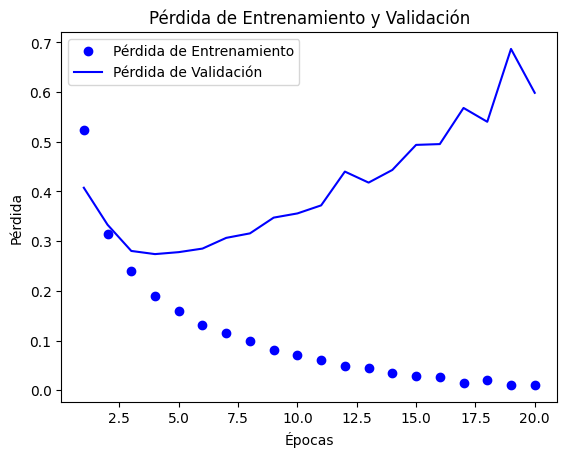

In [26]:
loss_values = modelo_dict['loss']
val_loss_values = modelo_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

In [27]:
results=model.evaluate(x_test, y_test)
results

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8513 - loss: 0.6611


[0.6610915064811707, 0.8512799739837646]

## Reduciendo Overfitting con Reducción de la Complejidad del Modelo (Quintando  neuronas)

In [28]:
model2=models.Sequential()
model2.add(layers.Dense(4, activation='relu', input_shape=(10000,)))
model2.add(layers.Dense(4, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))
model2.compile(optimizer='rmsprop',              
						loss='binary_crossentropy',
						metrics=['accuracy'])
modelo2=model2.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.4)
modelo_dict2=modelo2.history
loss_values2 = modelo_dict2['loss']
val_loss_values2 = modelo_dict2['val_loss']
epochs = range(1, len(loss_values2) + 1)


results=model2.evaluate(x_test, y_test)
results

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.7526 - loss: 0.5807 - val_accuracy: 0.8500 - val_loss: 0.4767
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8823 - loss: 0.4026 - val_accuracy: 0.8759 - val_loss: 0.3771
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9091 - loss: 0.3110 - val_accuracy: 0.8822 - val_loss: 0.3250
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9232 - loss: 0.2543 - val_accuracy: 0.8873 - val_loss: 0.2991
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9345 - loss: 0.2169 - val_accuracy: 0.8884 - val_loss: 0.2846
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9417 - loss: 0.1887 - val_accuracy: 0.8906 - val_loss: 0.2756
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9523 - loss: 0.1666 - val_accuracy: 0.8896 - val_loss: 0.2756
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9577 - loss: 0.1491 - val_accuracy: 0.8860 - v

[0.42842572927474976, 0.8626000285148621]

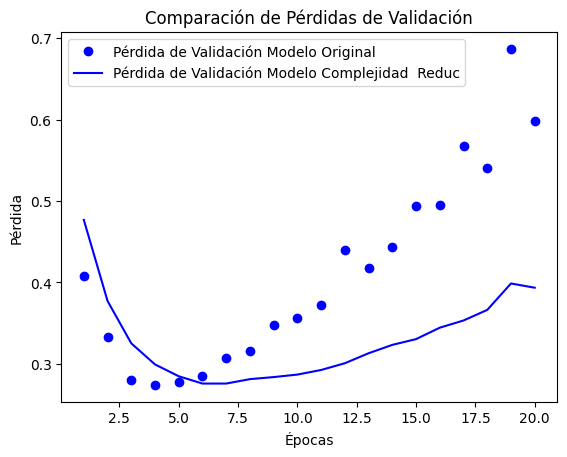

In [29]:
plt.plot(epochs, val_loss_values, 'bo', label='Pérdida de Validación Modelo Original')
plt.plot(epochs, val_loss_values2, 'b', label='Pérdida de Validación Modelo Complejidad  Reduc')
plt.title('Comparación de Pérdidas de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Reduciendo Overfitting con Regularización L2 (Agregando una penalización de peso)

In [30]:
from keras import regularizers

model3=models.Sequential()
model3.add(layers.Dense(16, activation='relu', input_shape=(10000,), kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(1, activation='sigmoid'))
model3.compile(optimizer='rmsprop',              
						loss='binary_crossentropy',
						metrics=['accuracy'])
modelo3=model3.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.4)
modelo_dict3=modelo3.history
loss_values3 = modelo_dict3['loss']
val_loss_values3 = modelo_dict3['val_loss']
epochs = range(1, len(loss_values3) + 1)


results=model3.evaluate(x_test, y_test)
results

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.7699 - loss: 0.5787 - val_accuracy: 0.8689 - val_loss: 0.4461
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8927 - loss: 0.3801 - val_accuracy: 0.8809 - val_loss: 0.3685
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9145 - loss: 0.3047 - val_accuracy: 0.8871 - val_loss: 0.3401
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9307 - loss: 0.2634 - val_accuracy: 0.8875 - val_loss: 0.3361
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9389 - loss: 0.2407 - val_accuracy: 0.8805 - val_loss: 0.3541
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9467 - loss: 0.2223 - val_accuracy: 0.8862 - val_loss: 0.3450
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9523 - loss: 0.2069 - val_accuracy: 0.8669 - val_loss: 0.3916
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9534 - loss: 0.2007 - val_accuracy: 0.8751 - v

[0.4666211009025574, 0.8649600148200989]

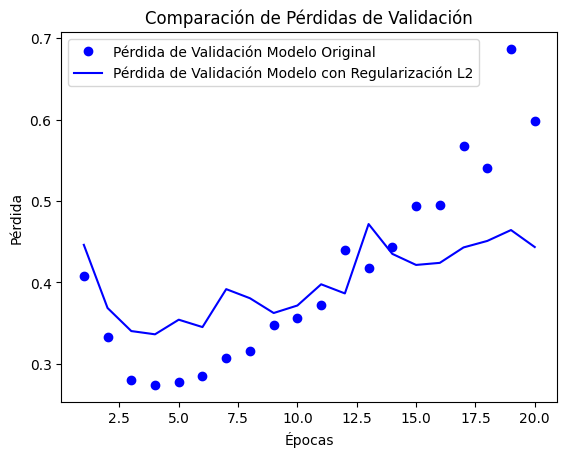

In [31]:
plt.plot(epochs, val_loss_values, 'bo', label='Pérdida de Validación Modelo Original')
plt.plot(epochs, val_loss_values3, 'b', label='Pérdida de Validación Modelo con Regularización L2')
plt.title('Comparación de Pérdidas de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Reduciendo Overfitting con Regularización L1 y L2 (Agregando una penalización de peso)

In [44]:
model4=models.Sequential()
model4.add(layers.Dense(16, activation='relu', input_shape=(10000,), kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)))
model4.add(layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)))
model4.add(layers.Dense(1, activation='sigmoid'))
model4.compile(optimizer='rmsprop',              
						loss='binary_crossentropy',
						metrics=['accuracy'])
modelo4=model4.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.4)
modelo_dict4=modelo4.history
loss_values4 = modelo_dict4['loss']
val_loss_values4 = modelo_dict4['val_loss']
epochs = range(1, len(loss_values4) + 1)


results=model4.evaluate(x_test, y_test)
results

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.7411 - loss: 1.1618 - val_accuracy: 0.7877 - val_loss: 0.7493
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8344 - loss: 0.6924 - val_accuracy: 0.8499 - val_loss: 0.6656
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8455 - loss: 0.6390 - val_accuracy: 0.8559 - val_loss: 0.6286
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8544 - loss: 0.6084 - val_accuracy: 0.8589 - val_loss: 0.6018
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8634 - loss: 0.5802 - val_accuracy: 0.8535 - val_loss: 0.5945
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8607 - loss: 0.5675 - val_accuracy: 0.8517 - val_loss: 0.5931
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8629 - loss: 0.5568 - val_accuracy: 0.8630 - val_loss: 0.5587
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8671 - loss: 0.5474 - val_accuracy: 0.8630 - v

[0.5368527173995972, 0.8606799840927124]

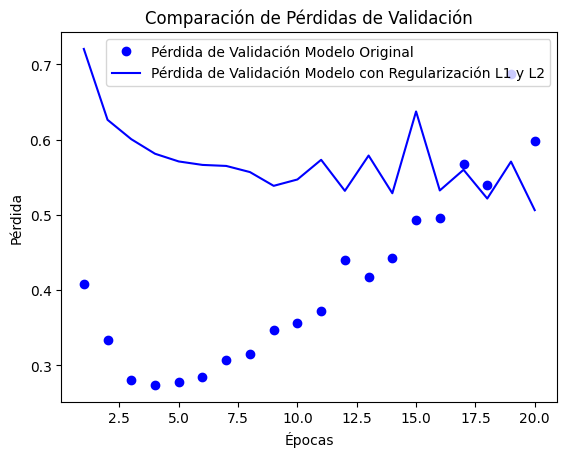

In [33]:
plt.plot(epochs, val_loss_values, 'bo', label='Pérdida de Validación Modelo Original')
plt.plot(epochs, val_loss_values4, 'b', label='Pérdida de Validación Modelo con Regularización L1 y L2')
plt.title('Comparación de Pérdidas de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Reduciendo Overfitting con Dropout

In [34]:
model5=models.Sequential()
model5.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model5.add(layers.Dropout(0.5))
model5.add(layers.Dense(16, activation='relu'))
model5.add(layers.Dropout(0.5))
model5.add(layers.Dense(1, activation='sigmoid'))
model5.compile(optimizer='rmsprop',              
						loss='binary_crossentropy',
						metrics=['accuracy'])
modelo5=model5.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.4)
modelo_dict5=modelo5.history
loss_values5 = modelo_dict5['loss']
val_loss_values5 = modelo_dict5['val_loss']
epochs = range(1, len(loss_values5) + 1)


results=model5.evaluate(x_test, y_test)
results

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6257 - loss: 0.6410 - val_accuracy: 0.8020 - val_loss: 0.5435
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7574 - loss: 0.5254 - val_accuracy: 0.8656 - val_loss: 0.4124
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8161 - loss: 0.4428 - val_accuracy: 0.8771 - val_loss: 0.3512
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8529 - loss: 0.3746 - val_accuracy: 0.8815 - val_loss: 0.3060
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8768 - loss: 0.3208 - val_accuracy: 0.8885 - val_loss: 0.2823
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8967 - loss: 0.2834 - val_accuracy: 0.8913 - val_loss: 0.2762
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9116 - loss: 0.2463 - val_accuracy: 0.8899 - val_loss: 0.2780
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9235 - loss: 0.2180 - val_accuracy: 0.8907 - v

[0.5718562006950378, 0.8745200037956238]

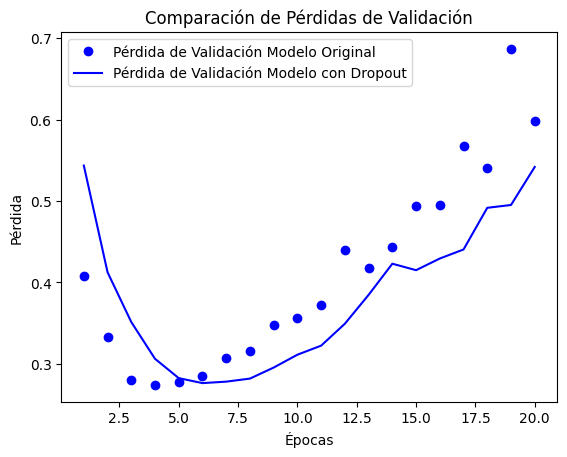

In [35]:
plt.plot(epochs, val_loss_values, 'bo', label='Pérdida de Validación Modelo Original')
plt.plot(epochs, val_loss_values5, 'b', label='Pérdida de Validación Modelo con Dropout')
plt.title('Comparación de Pérdidas de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Combinando Regularizadores y Dropout

In [36]:
model6=models.Sequential()
model6.add(layers.Dense(4, activation='relu', input_shape=(10000,), kernel_regularizer=regularizers.l2(l2=0.001)))
model6.add(layers.Dropout(0.5))
model6.add(layers.Dense(4, activation='relu', kernel_regularizer=regularizers.l2(l2=0.001)))
model6.add(layers.Dropout(0.5))
model6.add(layers.Dense(1, activation='sigmoid'))
model6.compile(optimizer='rmsprop',              
						loss='binary_crossentropy',
						metrics=['accuracy'])
modelo6=model6.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.4)
modelo_dict6=modelo6.history
loss_values6 = modelo_dict6['loss']
val_loss_values6 = modelo_dict6['val_loss']
epochs = range(1, len(loss_values6) + 1)


results=model6.evaluate(x_test, y_test)
results

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.5623 - loss: 0.6846 - val_accuracy: 0.7721 - val_loss: 0.6283
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6261 - loss: 0.6344 - val_accuracy: 0.8536 - val_loss: 0.5810
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6475 - loss: 0.6021 - val_accuracy: 0.8631 - val_loss: 0.5297
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6601 - loss: 0.5805 - val_accuracy: 0.8730 - val_loss: 0.5075
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6741 - loss: 0.5587 - val_accuracy: 0.8775 - val_loss: 0.4882
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6844 - loss: 0.5422 - val_accuracy: 0.8752 - val_loss: 0.4602
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6899 - loss: 0.5252 - val_accuracy: 0.8696 - val_loss: 0.4613
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6899 - loss: 0.5226 - val_accuracy: 0.8790 - v

[0.34819862246513367, 0.8762400150299072]

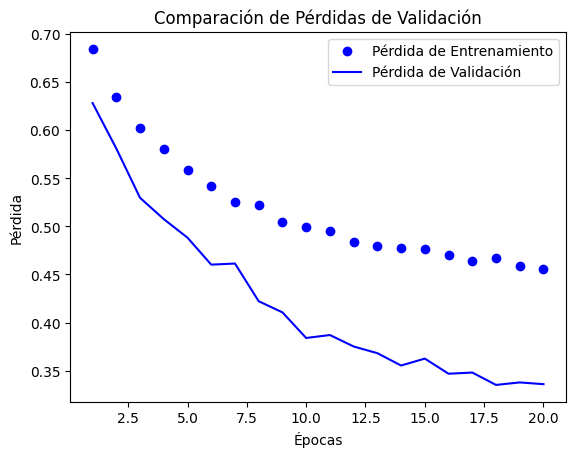

In [47]:
plt.plot(epochs, loss_values6, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values6, 'b', label='Pérdida de Validación')
plt.title('Comparación de Pérdidas de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Mejoramiento del Modelo Aumentando el Número de Épocas

In [48]:
model7=models.Sequential()
model7.add(layers.Dense(4, activation='relu', input_shape=(10000,), kernel_regularizer=regularizers.l2(l2=0.001)))
model7.add(layers.Dropout(0.5))
model7.add(layers.Dense(4, activation='relu', kernel_regularizer=regularizers.l2(l2=0.001)))
model7.add(layers.Dropout(0.5))
model7.add(layers.Dense(1, activation='sigmoid'))
model7.compile(optimizer='rmsprop',              
						loss='binary_crossentropy',
						metrics=['accuracy'])
modelo7=model7.fit(x_train, y_train, epochs=40, batch_size=512, validation_split=0.4)
modelo_dict7=modelo7.history
loss_values7 = modelo_dict7['loss']
val_loss_values7 = modelo_dict7['val_loss']
epochs = range(1, len(loss_values7) + 1)


results=model7.evaluate(x_test, y_test)
results

Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5349 - loss: 0.6847 - val_accuracy: 0.8075 - val_loss: 0.6398
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5803 - loss: 0.6352 - val_accuracy: 0.8511 - val_loss: 0.5844
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6505 - loss: 0.6090 - val_accuracy: 0.8642 - val_loss: 0.5476
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6595 - loss: 0.5908 - val_accuracy: 0.8768 - val_loss: 0.5345
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6729 - loss: 0.5733 - val_accuracy: 0.8793 - val_loss: 0.4937
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.6852 - loss: 0.5634 - val_accuracy: 0.8793 - val_loss: 0.4684
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6871 - loss: 0.5572 - val_accuracy: 0.8838 - val_loss: 0.4630
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7028 - loss: 0.5406 - val_accuracy: 0.8719 - v

[0.3615998327732086, 0.8748800158500671]

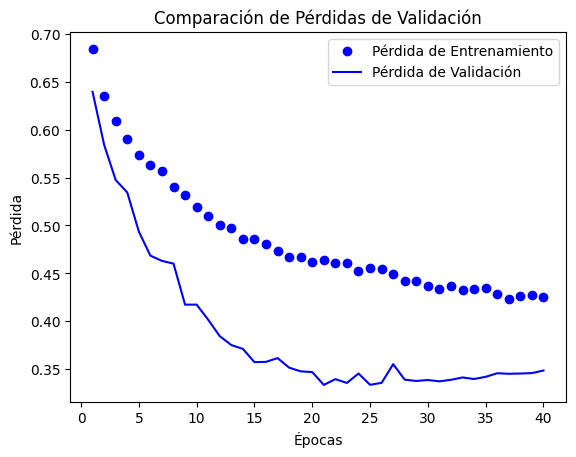

In [49]:
plt.plot(epochs, loss_values7, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values7, 'b', label='Pérdida de Validación')
plt.title('Comparación de Pérdidas de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

In [50]:
model8=models.Sequential()
model8.add(layers.Dense(4, activation='relu', input_shape=(10000,), kernel_regularizer=regularizers.l2(l2=0.001)))
model8.add(layers.Dropout(0.5))
model8.add(layers.Dense(4, activation='relu', kernel_regularizer=regularizers.l2(l2=0.001)))
model8.add(layers.Dropout(0.5))
model8.add(layers.Dense(1, activation='sigmoid'))
model8.compile(optimizer='rmsprop',              
						loss='binary_crossentropy',
						metrics=['accuracy'])
modelo8=model8.fit(x_train, y_train, epochs=25, batch_size=512, validation_split=0.4)
modelo_dict8=modelo8.history
loss_values8 = modelo_dict8['loss']
val_loss_values8 = modelo_dict8['val_loss']
epochs = range(1, len(loss_values8) + 1)


results=model8.evaluate(x_test, y_test)
results

Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5323 - loss: 0.6941 - val_accuracy: 0.8079 - val_loss: 0.6767
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5798 - loss: 0.6727 - val_accuracy: 0.8028 - val_loss: 0.6529
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6045 - loss: 0.6501 - val_accuracy: 0.8536 - val_loss: 0.6234
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6163 - loss: 0.6332 - val_accuracy: 0.8609 - val_loss: 0.6044
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6261 - loss: 0.6138 - val_accuracy: 0.8674 - val_loss: 0.5768
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.6412 - loss: 0.5990 - val_accuracy: 0.8717 - val_loss: 0.5516
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6630 - loss: 0.5808 - val_accuracy: 0.8733 - val_loss: 0.5381
Epoch 8/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6767 - loss: 0.5698 - val_accuracy: 0.8750 - v

[0.36992257833480835, 0.8773999810218811]

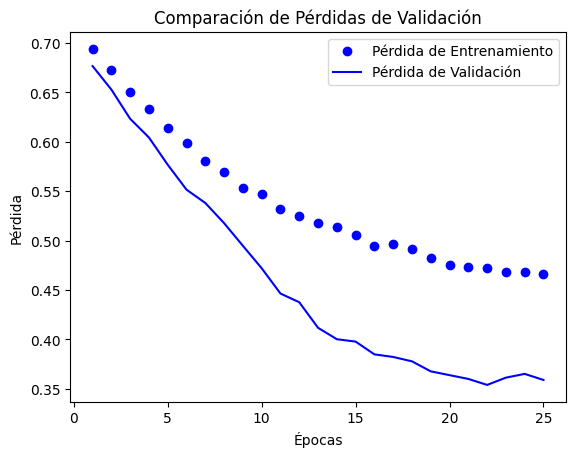

In [51]:
plt.plot(epochs, loss_values8, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values8, 'b', label='Pérdida de Validación')
plt.title('Comparación de Pérdidas de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

In [ ]:
model9=models.Sequential()
model9.add(layers.Dense(4, activation='relu', input_shape=(10000,), kernel_regularizer=regularizers.l2(l2=0.001)))
model9.add(layers.Dropout(0.5))
model9.add(layers.Dense(4, activation='relu', kernel_regularizer=regularizers.l2(l2=0.001)))
model9.add(layers.Dropout(0.5))
model9.add(layers.Dense(1, activation='sigmoid'))
model9.compile(optimizer='rmsprop',              
						loss='binary_crossentropy',
						metrics=['accuracy'])
modelo9=model9.fit(x_train, y_train, epochs=25, batch_size=512, validation_split=0.4)
modelo_dict9=modelo9.history
loss_values9 = modelo_dict9['loss']
val_loss_values9 = modelo_dict9['val_loss']
epochs = range(1, len(loss_values9) + 1)


results=model9.evaluate(x_test, y_test)
results

Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.5564 - loss: 0.6883 - val_accuracy: 0.6989 - val_loss: 0.6530
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6335 - loss: 0.6618 - val_accuracy: 0.8403 - val_loss: 0.6276
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6777 - loss: 0.6418 - val_accuracy: 0.8561 - val_loss: 0.6064
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6923 - loss: 0.6280 - val_accuracy: 0.7915 - val_loss: 0.5738
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7075 - loss: 0.6132 - val_accuracy: 0.8485 - val_loss: 0.5574
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7075 - loss: 0.6088 - val_accuracy: 0.8772 - val_loss: 0.5618
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7165 - loss: 0.5963 - val_accuracy: 0.8777 - val_loss: 0.5439
Epoch 8/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7196 - loss: 0.5897 - val_accuracy: 0.8787 - v

[0.4419567883014679, 0.8678799867630005]

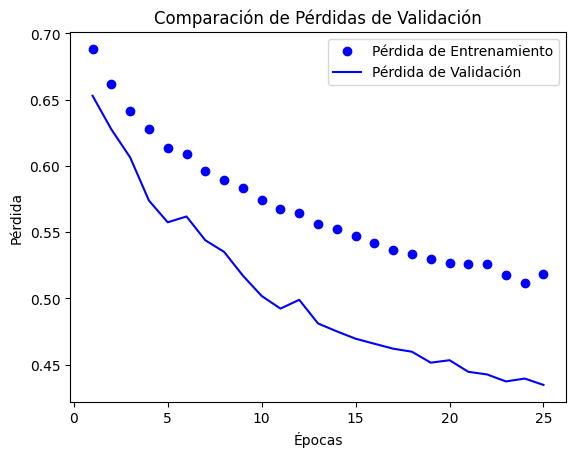

In [53]:
plt.plot(epochs, loss_values9, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values9, 'b', label='Pérdida de Validación')
plt.title('Comparación de Pérdidas de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()